# Data Quality Deep Dive

Цель: понять, насколько данные пригодны для модели предиктивного обслуживания. Здесь отдельно смотрим пропуски, row-level деградацию, стабильность train/test и признаки, которые потенциально стоит исключать или аккуратно обрабатывать.


In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.cache' / 'matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(PROJECT_ROOT))

from src.aps_failure.data import load_dataset, make_data_quality_report

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)

train_path = PROJECT_ROOT / 'data/raw/aps_failure_training_set.csv'
test_path = PROJECT_ROOT / 'data/raw/aps_failure_test_set.csv'
x_train, y_train = load_dataset(train_path)
x_test, y_test = load_dataset(test_path)
print(f'train: {x_train.shape}, test: {x_test.shape}')


train: (60000, 170), test: (16000, 170)


## Паспорт данных

Сводка фиксирует размер выборок, количество признаков, долю APS-positive и общий уровень пропусков.


In [2]:
quality = make_data_quality_report(x_train, y_train, x_test, y_test)
pd.Series(quality).drop('top_missing_features')


train_rows                      60000
test_rows                       16000
feature_count                     170
train_positive                   1000
train_negative                  59000
test_positive                     375
test_negative                   15625
positive_rate_train          0.016667
positive_rate_test           0.023438
missing_cells_train_ratio    0.083335
dtype: object

In [3]:
feature_quality = pd.DataFrame(
    {
        'missing_train': x_train.isna().mean(),
        'missing_test': x_test.isna().mean(),
        'unique_train': x_train.nunique(dropna=True),
        'zero_share_train': (x_train == 0).mean(),
        'mean_train': x_train.mean(numeric_only=True),
        'mean_test': x_test.mean(numeric_only=True),
        'std_train': x_train.std(numeric_only=True),
        'std_test': x_test.std(numeric_only=True),
    }
)
feature_quality['missing_delta'] = feature_quality['missing_test'] - feature_quality['missing_train']
feature_quality['mean_delta_scaled'] = (
    (feature_quality['mean_test'] - feature_quality['mean_train']).abs()
    / feature_quality['std_train'].replace(0, np.nan)
)
feature_quality.sort_values('missing_train', ascending=False).head(30)


,missing_train,missing_test,unique_train,zero_share_train,mean_train,mean_test,std_train,std_test,missing_delta,mean_delta_scaled
br_000,0.821067,0.820562,3806,0.030217,6.048866e+05,5.878845e+05,5.472279e+05,5.389677e+05,-0.000504,0.031070
bq_000,0.812033,0.811312,4276,0.028900,5.828713e+05,5.678459e+05,5.366970e+05,5.284812e+05,-0.000721,0.027996
bp_000,0.795667,0.795063,4968,0.026867,5.513898e+05,5.386857e+05,5.196114e+05,5.121671e+05,-0.000604,0.024449
bo_000,0.772217,0.773500,5838,0.025050,5.131478e+05,5.032822e+05,4.973537e+05,4.908516e+05,0.001283,0.019836
ab_000,0.772150,0.772687,29,0.182950,7.131885e-01,7.720649e-01,3.478962e+00,2.589224e+00,0.000537,0.016924
cr_000,0.772150,0.772687,74,0.226533,3.706298e+01,5.002310e+01,1.027001e+03,1.086268e+03,0.000537,0.012619
bn_000,0.733483,0.732062,7096,0.023700,4.637108e+05,4.573471e+05,4.644473e+05,4.591682e+05,-0.001421,0.013702
bm_000,0.659150,0.659125,9037,0.020233,3.996032e+05,4.006147e+05,4.070718e+05,4.066597e+05,-0.000025,0.002485
bl_000,0.454617,0.451625,11969,0.016933,3.213537e+05,3.204830e+05,3.192110e+05,3.149868e+05,-0.002992,0.002728
bk_000,0.383900,0.380875,12917,0.008367,2.804291e+05,2.802005e+05,2.613015e+05,2.584001e+05,-0.003025,0.000875


## Распределение пропусков по признакам

Так видно, является ли missingness локальной проблемой нескольких датчиков или общей особенностью всего датасета.


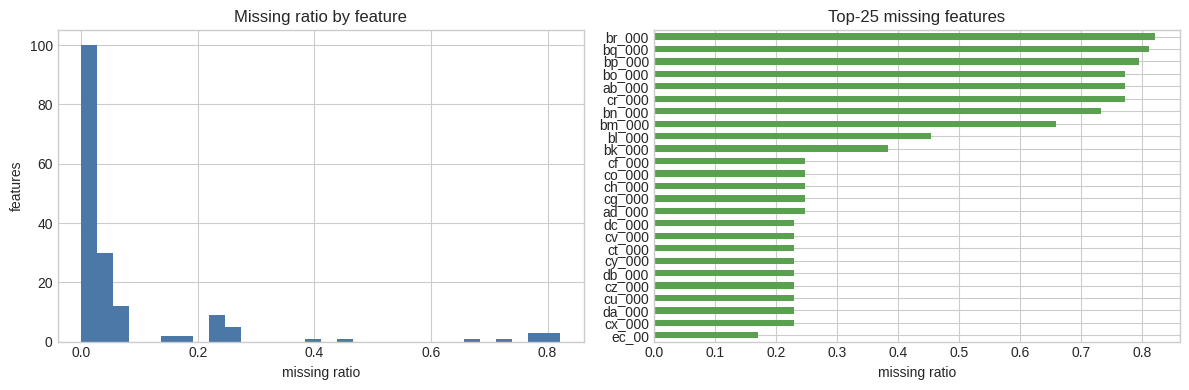

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
feature_quality['missing_train'].hist(bins=30, ax=axes[0], color='#4c78a8')
axes[0].set_title('Missing ratio by feature')
axes[0].set_xlabel('missing ratio')
axes[0].set_ylabel('features')
feature_quality.sort_values('missing_train', ascending=False).head(25).sort_values('missing_train')['missing_train'].plot(
    kind='barh', ax=axes[1], color='#59a14f'
)
axes[1].set_title('Top-25 missing features')
axes[1].set_xlabel('missing ratio')
plt.tight_layout()


In [5]:
missing_buckets = pd.cut(
    feature_quality['missing_train'],
    bins=[-0.001, 0.01, 0.05, 0.20, 0.50, 0.80, 1.0],
    labels=['<=1%', '1-5%', '5-20%', '20-50%', '50-80%', '80-100%'],
)
missing_buckets.value_counts().sort_index().rename('feature_count').to_frame()


,feature_count
missing_train,
<=1%,10
1-5%,118
5-20%,18
20-50%,16
50-80%,6
80-100%,2


## Row-level качество

Если у positive-строк больше пропусков, сама структура отсутствующих значений может быть полезным сигналом. Если наоборот пропуски равномерны, их лучше рассматривать как шум/особенность источника.


In [6]:
row_quality = pd.DataFrame(
    {
        'target': y_train.map({0: 'neg', 1: 'pos'}),
        'missing_features': x_train.isna().sum(axis=1),
        'missing_ratio': x_train.isna().mean(axis=1),
        'zero_features': (x_train == 0).sum(axis=1),
        'zero_ratio': (x_train == 0).mean(axis=1),
    }
)
row_quality.groupby('target').agg(
    rows=('target', 'size'),
    missing_ratio_mean=('missing_ratio', 'mean'),
    missing_ratio_median=('missing_ratio', 'median'),
    missing_ratio_p90=('missing_ratio', lambda s: s.quantile(0.90)),
    zero_ratio_mean=('zero_ratio', 'mean'),
    zero_ratio_median=('zero_ratio', 'median'),
)


,rows,missing_ratio_mean,missing_ratio_median,missing_ratio_p90,zero_ratio_mean,zero_ratio_median
target,,,,,,
neg,59000,0.081841,0.047059,0.141176,0.321062,0.311765
pos,1000,0.171488,0.120588,0.352941,0.205435,0.200000


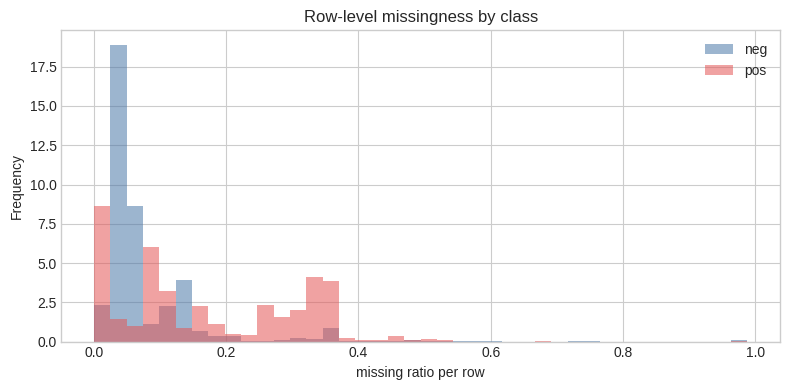

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [('neg', '#4c78a8'), ('pos', '#e45756')]:
    row_quality.loc[row_quality['target'] == label, 'missing_ratio'].plot(
        kind='hist', bins=40, alpha=0.55, density=True, ax=ax, color=color, label=label
    )
ax.set_title('Row-level missingness by class')
ax.set_xlabel('missing ratio per row')
ax.legend()
plt.tight_layout()


## Стабильность train/test

Проверяем два вида drift: изменение доли пропусков и грубый PSI по распределениям значений. Это не статистический тест качества модели, но хороший early-warning для продакшена.


In [8]:
def psi_for_feature(train_s: pd.Series, test_s: pd.Series, bins: int = 10) -> float:
    train_v = train_s.dropna().astype(float)
    test_v = test_s.dropna().astype(float)
    if train_v.nunique() < 3 or test_v.nunique() < 3:
        return np.nan
    edges = np.unique(np.nanquantile(train_v, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return np.nan
    edges[0] = -np.inf
    edges[-1] = np.inf
    train_counts = pd.cut(train_v, edges, include_lowest=True).value_counts(sort=False)
    test_counts = pd.cut(test_v, edges, include_lowest=True).value_counts(sort=False)
    train_pct = (train_counts / train_counts.sum()).replace(0, 1e-6)
    test_pct = (test_counts / test_counts.sum()).replace(0, 1e-6)
    return float(((test_pct - train_pct) * np.log(test_pct / train_pct)).sum())

psi_rows = []
for column in x_train.columns:
    if feature_quality.loc[column, 'missing_train'] <= 0.6 and feature_quality.loc[column, 'unique_train'] >= 3:
        psi_rows.append({'feature': column, 'psi': psi_for_feature(x_train[column], x_test[column])})
psi = pd.DataFrame(psi_rows).dropna().sort_values('psi', ascending=False)
psi.head(25)


,feature,psi
113,ct_000,0.001387
23,ap_000,0.001322
98,cn_008,0.001243
2,ad_000,0.001107
78,bz_000,0.001102
104,cs_001,0.001095
114,cu_000,0.001088
95,cn_005,0.001063
10,ag_005,0.001047
145,eb_000,0.001042


In [9]:
drift_table = feature_quality.join(psi.set_index('feature'), how='left')
drift_table['psi_flag'] = pd.cut(
    drift_table['psi'],
    bins=[-np.inf, 0.1, 0.25, np.inf],
    labels=['low', 'medium', 'high'],
)
drift_table.sort_values(['psi', 'missing_delta'], ascending=[False, False]).head(30)[
    ['missing_train', 'missing_test', 'missing_delta', 'mean_delta_scaled', 'psi', 'psi_flag']
]


,missing_train,missing_test,missing_delta,mean_delta_scaled,psi,psi_flag
ct_000,0.230133,0.232375,0.002242,0.000762,0.001387,low
ap_000,0.010700,0.010563,-0.000137,0.023378,0.001322,low
cn_008,0.011450,0.012125,0.000675,0.010831,0.001243,low
ad_000,0.247683,0.248812,0.001129,0.004707,0.001107,low
bz_000,0.045383,0.047688,0.002304,0.011205,0.001102,low
cs_001,0.011150,0.011813,0.000662,0.005971,0.001095,low
cu_000,0.230133,0.232375,0.002242,0.003231,0.001088,low
cn_005,0.011450,0.012125,0.000675,0.011367,0.001063,low
ag_005,0.011183,0.011813,0.000629,0.020683,0.001047,low
eb_000,0.066783,0.068375,0.001592,0.023120,0.001042,low


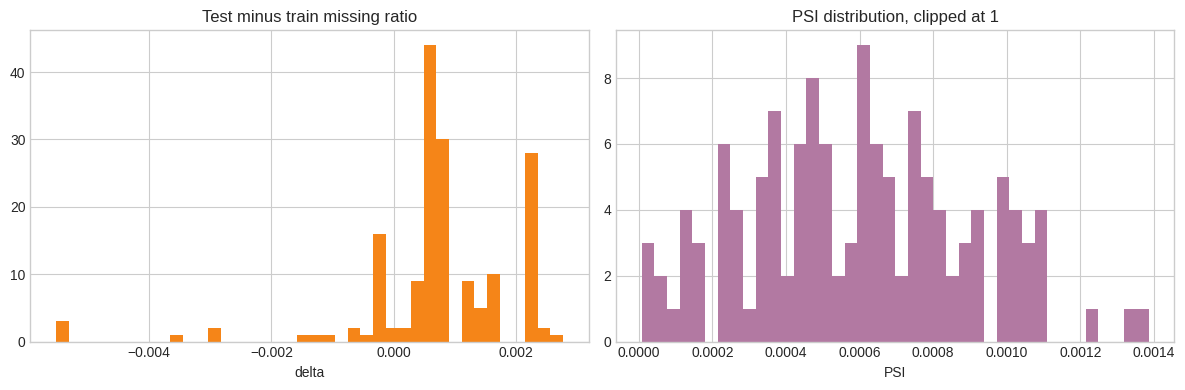

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
feature_quality['missing_delta'].hist(bins=40, ax=axes[0], color='#f58518')
axes[0].set_title('Test minus train missing ratio')
axes[0].set_xlabel('delta')
psi['psi'].clip(upper=1).hist(bins=40, ax=axes[1], color='#b279a2')
axes[1].set_title('PSI distribution, clipped at 1')
axes[1].set_xlabel('PSI')
plt.tight_layout()


## Кандидаты на ручную проверку

Сюда попадают признаки с экстремальной долей пропусков, почти константные признаки и признаки с заметным train/test сдвигом.


In [11]:
flags = pd.DataFrame(index=x_train.columns)
flags['very_high_missing'] = feature_quality['missing_train'] > 0.75
flags['almost_constant'] = feature_quality['unique_train'] <= 1
flags['mostly_zero'] = feature_quality['zero_share_train'] > 0.98
flags['missing_delta_gt_5pp'] = feature_quality['missing_delta'].abs() > 0.05
flags['psi_high'] = drift_table['psi'] > 0.25
flags['flag_count'] = flags.sum(axis=1)
flags.join(feature_quality[['missing_train', 'missing_test', 'unique_train', 'zero_share_train']]).join(
    drift_table[['psi']]
).query('flag_count > 0').sort_values(['flag_count', 'missing_train'], ascending=False)


,very_high_missing,almost_constant,mostly_zero,missing_delta_gt_5pp,psi_high,flag_count,missing_train,missing_test,unique_train,zero_share_train,psi
br_000,True,False,False,False,False,1,0.821067,0.820562,3806,0.030217,NaN
bq_000,True,False,False,False,False,1,0.812033,0.811312,4276,0.028900,NaN
bp_000,True,False,False,False,False,1,0.795667,0.795063,4968,0.026867,NaN
bo_000,True,False,False,False,False,1,0.772217,0.773500,5838,0.025050,NaN
ab_000,True,False,False,False,False,1,0.772150,0.772687,29,0.182950,NaN
cr_000,True,False,False,False,False,1,0.772150,0.772687,74,0.226533,NaN
cd_000,False,True,False,False,False,1,0.011267,0.011562,1,0.000000,NaN
ag_000,False,False,True,False,False,1,0.011183,0.011813,154,0.985550,NaN
as_000,False,False,True,False,False,1,0.010483,0.010188,21,0.989167,NaN
au_000,False,False,True,False,False,1,0.010483,0.010188,56,0.988500,NaN
